
<h1 align="center">Genetic Programming's Application in A-shares Alpha Extraction</h1>


### Important Notice to Readers - Framework Validation and Scope Limitations


This notebook serves as a structurally complete, end-to-end Proof of Concept (PoC) demonstrating the viability of utilizing Genetic Programming for quantitative alpha mining. To maintain the advantage of a completely standalone pipeline—allowing users to execute the entire system instantly in a basic local notebook environment within a 5–10 minute window, specific data and parameter compromises have been intentionally implemented:

1. The asset universe is restricted to a small sample size over a compressed historical time interval.

2. Operational parameters and threshold filters are heuristic and arbitrary rather than optimized.

3. The mathematical engine utilizes forward returns as its singular optimization target.

Consequently, while the un-optimized out-of-sample performance figures displayed below are not production-ready or directly tradeable, they successfully confirm that the structural framework is entirely viable and free of design flaws.

You are encouraged to scale this infrastructure to production levels by expanding the input data dimensions (enlarging the stock universe and extending the historical timeline), incorporating advanced multi-objective targets, and conducting rigorous hyperparameter tuning to unlock institutional-grade predictive outcomes.


### Overview

This self-contained project establishes an end-to-end quantitative pipeline using Genetic Programming (GP) to mine unique, high-performing alpha factors from the Chinese A-share market.




### Setup

Data Sources: OpenBB and Yahoo Finance

Universe Size: 64 liquid A-share symbols

Expected Runtime: 5-10 minutes

### Core Pipeline

1. Data ingestion and panel normalization.

2. Genetic Programming evolution over the training window.

3. Selection of top-performing mathematical expressions via a Hall-of-Fame structure.

4. Cross-sectional decorrelation to strip out redundant or cloning signals.

5. Final generation of the robust alpha library.


### Code Readability & Documentation Note

To ensure this framework bridges the gap between academic theory and practical application, I have written extensive inline annotations throughout the entire script. Every mathematical operator, tensor transformation, and logic loop is explicitly broken down at a beginner-friendly level. Even if you are entirely new to Genetic Programming or quantitative backtesting frameworks, you will be able to follow the step-by-step logic, modify the underlying equations, and understand exactly how data moves through the pipeline without structural difficulties.

In [1]:
%pip install -q openbb openbb-yfinance pandas numpy matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


<h1 align="center">Library Section</h1>


### Environment Configurations & Hyperparameters**

This cell serves as the operational command center for the entire pipeline. It imports numerical modules, prevents cluttered warning text, sets predictable random seeds, and defines required parameters:

In [14]:
import random
import warnings
import time
from dataclasses import dataclass
from typing import Any
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kw): return x

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

random.seed(42)
np.random.seed(42)

# Universe
SYMBOLS = ['600519', '601318', '600036', '601166', '600900', '600030', '601012', '600276', '601888', '600000', '601398', '601288', '601939', '601328', '600887', '603259', '601857', '600309', '601668', '600690', '601601', '600809', '601988', '600048', '601628', '600585', '601818', '600104', '601688', '600031', '601766', '600050', '601390', '600196', '601225', '600741', '601127', '600660', '601336', '600406', '000858', '000333', '300750', '002594', '300059', '000001', '000002', '000725', '002415', '000568', '002304', '300015', '000063', '002352', '300124', '000651', '002142', '300274', '000776', '002230', '300498', '000538', '002460', '300014']
# A list of 64 specific stock tickers from the Chinese A-share market
MIN_LOADED = 40          # Min tickers required from OpenBB

# GP knobs
TARGET_N = 100             # Maximum number of high-quality alpha factors saved into final library
POP_SIZE = 60              # Number of formulas alive simultaneously in each generation
GENERATIONS = 12           # Number of evolutionary cycles
MAX_DEPTH = 4              # How deep an equation tree can grow
CROSSOVER_RATE = 0.7       # Chance that two strong parents will create child factor
MUTATION_RATE = 0.35       # Chance that a random part of a formula will mutate
TOURNAMENT_K = 3           # When choosing formulas to breed, randomly grab 3 equations and picks the single best one among them
ELITE_N = 6                # Top 6 best-performing formulas in every generation are guaranteed to survive into next generation without being altered by mutation or crossover
HALL_OF_FAME = 500         # Storage retaining top 500 formulas discovered across the entire evolutionary process
CORR_THRESH = 0.65         # Maximum allowed correlation between factors
MIN_IC_DAYS = 30           # A factor must have at least 30 valid trading days of Information Coefficient
MIN_CS_NAMES = 20          # There must be data available for at least 20 distinct stocks to calculate cross-sectional score
MAX_ZERO_FRAC = 0.25       # Throw out degenerate factors if more than 25% of their generated values turn out to be exactly zero or static

START, END = "2023-01-01", "2024-06-30"
TRAIN_END = "2024-01-01"   # GP + selection use dates <= this
TEST_START = "2024-01-01"  # OOS evaluation uses dates >= this
FWD_HORIZON = 5            # Forward target horizon

# OOS filters for effective factors
OOS_MIN_DAYS = 15          # Factor must have valid predictive results for at least 15 days during OOS
OOS_MIN_IR = 0.10          # Minimum acceptable Out-of-Sample Information Ratio
OOS_MIN_IC = 0.0           # Minimum acceptable Information Coefficient
OOS_IR_DECAY_MIN = 0.40    # oos_ir / is_ir must exceed this
WINDOWS = (3, 5, 6, 8, 10, 15, 20)   # Alternative lengths of rolling windows

DATA_PROVIDER = "openbb"             # "openbb" or "synthetic"
OPENBB_PROVIDER = "yfinance"         # Yahoo Finance as the target data engine backing OpenBB
FETCH_SLEEP = 0.15                   # Prevent script from hitting server rate limits


### Data Panel Alignment & Alpha Operator Library

This cell acts as the data-processing engine room of the pipeline, converting raw market data into aligned, uniform matrices and building a robust library of mathematical operators for the Genetic Programming algorithm. It also provides a structured toolkit of Time-Series operators (rolling statistics) and Cross-Sectional operators (compare stocks against each other on a specific trading day), packaging them into a uniform dictionary directory for plug-and-play genetic evolution.

In [3]:

def safe_div(num, den):
    return (num / den.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)


def derive_fields(panel):
    out = dict(panel)
    if "vwap" not in out:
        out["vwap"] = safe_div(out["amount"], out["volume"]) if "amount" in out else (out["high"] + out["low"] + out["close"]) / 3.0
    if "ret" not in out:
        out["ret"] = out["close"].pct_change()
    out["range_pct"] = safe_div(out["high"] - out["low"], out["close"])
    out["body_pct"] = safe_div(out["close"] - out["open"], out["open"])
    out["pressure"] = safe_div((out["close"] - out["low"]) - (out["high"] - out["close"]), out["high"] - out["low"])
    return out


def align_panels(panels):
    idx = cols = None
    for df in panels.values():
        idx = df.index if idx is None else idx.union(df.index)
        cols = df.columns if cols is None else cols.union(df.columns)
    return {k: v.reindex(index=idx.sort_values(), columns=cols.sort_values()) for k, v in panels.items()}
# Output a standard Python dictionary that contains dataframes identical in row index and columns
# Arrange in chronological or numerical order


# Time Series Operators
def ts_delta(x, n=1): return x - x.shift(n)                                    # Absolute changes
def ts_delay(x, n=1): return x.shift(n)                                        # Whats the stock price n days ago
def ts_sum(x, n): return x.rolling(n, min_periods=n).sum()                     # Standard Moving Calculations
def ts_mean(x, n): return x.rolling(n, min_periods=n).mean()                   # Not return an answer unless it has a full n days of history
def ts_std(x, n): return x.rolling(n, min_periods=n).std()
def ts_max(x, n): return x.rolling(n, min_periods=n).max()
def ts_min(x, n): return x.rolling(n, min_periods=n).min()
def ts_corr(a, b, n): return a.rolling(n, min_periods=n).corr(b)               # Rolling Pearson correlation coefficient between two different feature matrices
def ts_log(x): return np.log(x.replace(0, np.nan))                             # Natural Logarithm

def ts_rank(x, n):                                                             # Exactly where that day's value stands relative to its own recent past
    def _last(w):                                                              # Will return pandas series
        s = pd.Series(w)
        return s.rank(pct=True).iloc[-1] if not s.isna().all() else np.nan
    return x.rolling(n, min_periods=n).apply(_last, raw=False)

# Cross Sectional
def cs_rank(x): return x.rank(axis=1, pct=True, method="average")              # Stock that gains most gets 1.0, worst performer gets 0.0.
def cs_scale(x): return x.div(x.abs().sum(axis=1).replace(0, np.nan), axis=0)  # Normalization


TS_UNARY = {
    "delta": lambda x, w: ts_delta(x, w),
    "delay": lambda x, w: ts_delay(x, w),
    "mean": lambda x, w: ts_mean(x, w),
    "std": lambda x, w: ts_std(x, w),
    "sum": lambda x, w: ts_sum(x, w),
    "max": lambda x, w: ts_max(x, w),
    "min": lambda x, w: ts_min(x, w),
    "tsrank": lambda x, w: ts_rank(x, w),
}
# Operator Library
# Unary operator with single input
# Call by TS_UNARY["tsrank"](panel["close"], 5)

### Data Ingestion & Fallback Architecture

This cell handles the data-loading layer of the pipeline, orchestrating the collection, cleanup, and alignment of multi-asset OHLCV (Open, High, Low, Close, Volume) panels. As a fallback, it features an automated fallback engine that automatically generates realistic multi-asset pricing data using Geometric Brownian Motion (GBM) simulations if live data connections fail. Finally, it uses structural threshold constraints to verify that enough assets loaded properly, concatenating the isolated asset series into a perfectly chronological, uniformly aligned multi-dimensional dictionary of DataFrames ready for math evaluations.

In [4]:

def to_yahoo_symbol(code: str) -> str:
    code = str(code).zfill(6)
    return f"{code}.SS" if code.startswith("6") else f"{code}.SZ"


def make_synthetic_panel(tickers, start, end, seed=42):
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start, end)          
    # Generates a chronological index of Business Days between start and end
    
    closes = [pd.Series(10 * np.exp(np.cumsum(rng.normal(0.0005, 0.02, len(dates)))), index=dates) for _ in tickers]
    close_df = pd.concat(closes, axis=1)
    close_df.columns = tickers
    shape = close_df.shape
    # Build a price history for each stock using Geometric Brownian Motion (GBM)
    
    high_df = close_df * (1 + rng.uniform(0.001, 0.02, shape))
    low_df = close_df * (1 - rng.uniform(0.001, 0.02, shape))
    open_df = close_df.shift(1).fillna(close_df.iloc[0]) * (1 + rng.normal(0, 0.005, shape))
    # Derive HLO
    
    vol_df = pd.DataFrame(rng.integers(1_000_000, 5_000_000, shape), index=dates, columns=tickers, dtype=float)
    return align_panels({
        "open": open_df, "high": high_df, "low": low_df, "close": close_df,
        "volume": vol_df, "amount": vol_df * close_df,
    })
    # Here assume VWAP=Close


def _normalize_ohlcv(df, local_code):
    out = df.copy()
    if not isinstance(out.index, pd.DatetimeIndex):
        out.index = pd.to_datetime(out.get("date", out.index))
    out.index = out.index.tz_localize(None) if getattr(out.index, "tz", None) else out.index
    # Strip time zone away
    out = out.sort_index()
    out = out.rename(columns={c: c.lower() for c in out.columns})
    need = ["open", "high", "low", "close", "volume"]
    if any(c not in out.columns for c in need):
        raise ValueError(f"{local_code}: missing OHLCV columns")
    if "amount" not in out.columns:
        out["amount"] = out["close"] * out["volume"]
    return out[need + ["amount"]]


def load_openbb_panel(symbols, start, end, provider=OPENBB_PROVIDER, sleep_sec=FETCH_SLEEP, min_loaded=MIN_LOADED):
    from openbb import obb

    buckets = {k: [] for k in ("open", "high", "low", "close", "volume", "amount")}
    failed = []

    for sym in tqdm(symbols, desc="OpenBB fetch"):
        ysym = to_yahoo_symbol(sym)
        try:
            result = obb.equity.price.historical(symbol=ysym, start_date=start, end_date=end, provider=provider)
            # Fetch the timeline matrix
            df = _normalize_ohlcv(result.to_dataframe(), sym)
            for field in buckets:
                buckets[field].append(df[field].rename(sym))
        except Exception as exc:
            failed.append((sym, str(exc)[:80]))
        time.sleep(sleep_sec)
        # Protect from being blocked for aggressive web scraping

    n_ok = len(buckets["close"])
    print(f"Loaded {n_ok}/{len(symbols)} tickers" + (f"  ({len(failed)} failed)" if failed else ""))
    min_required = min(min_loaded, max(30, int(len(symbols) * 0.75)))
    if n_ok < min_required:
        raise RuntimeError(f"Only {n_ok} tickers loaded (need ≥{min_required}). Try DATA_PROVIDER='synthetic'.")
    return align_panels({k: pd.concat(v, axis=1) for k, v in buckets.items()})
    # Min loading tickers check

def load_panel(symbols, start, end, provider=DATA_PROVIDER):
    if provider == "openbb":
        try:
            return load_openbb_panel(symbols, start, end), f"openbb/{OPENBB_PROVIDER}"
        except Exception as exc:
            print(f"OpenBB failed: {exc}")
            print("→ falling back to synthetic panel")
    return make_synthetic_panel(symbols, start, end), "synthetic"
    # Data loading with synthetic fallback


### Alpha Factor Tree Representation & Genetic Mutation Architecture

This cell acts as the core mathematical engine of the pipeline, translating quantitative alpha factors into dynamic Expression Trees that can be programmatically generated, evaluated, and evolved like biological organisms. It defines a recursive, immutable data structure to represent complex formulas, using tree recursion to evaluate raw data from the inside out. To mimic biological evolution, the cell establishes a tree-traversal system that assigns unique address paths to every mathematical node, allowing the algorithm to execute micro-surgeries like subtree crossovers (swapping code fragments between two successful parent formulas) and mutations (randomly shifting arguments or replacing entire branches with fresh formulas). Finally, these expressions are paired with their backtesting performance metrics inside an Individual container, providing a plug-and-play framework for automated, multi-generation strategy discovery.

In [5]:

@dataclass(frozen=True)
class Expr:
    op: str
    args: tuple[Any, ...] = ()
    # op = "field" (The Data Provider): represents the raw market data itself 
    # Its args hold a single string pointing to specific database column name
    # It tells the engine: "Go fetch this raw matrix."
    
    # op in TS_UNARY (The Math Operator): represents a rolling function (like "ts_mean" or "ts_std")
    # Its args hold a nested child expression tree and an integer window size
    # It tells the engine: "Take that data matrix and run a rolling historical calculation over it."
    def __repr__(self):
        return expr_str(self)

# Read-only
# Every single Expr object is a branch or a leaf on a math tree
# Entire structure nest smaller Expr objects inside larger ones
# Evolutionary algorithm can read, change, and breed formulas automatically

def expr_str(e):
    if e.op == "field": return e.args[0]
    if e.op == "neg": return f"-({expr_str(e.args[0])})"
    if e.op == "log": return f"log({expr_str(e.args[0])})"
    if e.op == "rank": return f"rank({expr_str(e.args[0])})"
    if e.op == "scale": return f"scale({expr_str(e.args[0])})"
    if e.op in TS_UNARY: return f"{e.op}({expr_str(e.args[0])},{e.args[1]})"
    if e.op == "corr": return f"corr({expr_str(e.args[0])},{expr_str(e.args[1])},{e.args[2]})"
    if e.op == "mul": return f"({expr_str(e.args[0])}*{expr_str(e.args[1])})"
    if e.op == "sub": return f"({expr_str(e.args[0])}-{expr_str(e.args[1])})"
    return str(e.op)
    # Flatten tree object into a clean, human-readable mathematical string
    # Example: Expr(op="ts_mean", args=(Expr(op="field", args=("close",)), 10)) to ts_mean(close,10)


def eval_expr(e, f):
    if e.op == "field": return f[e.args[0]]
    if e.op == "neg": return -eval_expr(e.args[0], f)
    if e.op == "log": return ts_log(eval_expr(e.args[0], f))
    if e.op == "rank": return cs_rank(eval_expr(e.args[0], f))
    if e.op == "scale": return cs_scale(eval_expr(e.args[0], f))
    if e.op in TS_UNARY: return TS_UNARY[e.op](eval_expr(e.args[0], f), e.args[1])
    if e.op == "corr": return ts_corr(eval_expr(e.args[0], f), eval_expr(e.args[1], f), e.args[2])
    if e.op == "mul": return eval_expr(e.args[0], f) * eval_expr(e.args[1], f)
    if e.op == "sub": return eval_expr(e.args[0], f) - eval_expr(e.args[1], f)
    raise ValueError(e.op)
    # Takes an abstract formula tree and evaluates it from the inside out using recursion
    # Start at the deepest leaves and work its way up to the outer operators
    # f is the 3D data cube where we can drag dataframe with keys

BASE_FIELDS = ["open", "high", "low", "close", "volume", "vwap", "ret", "range_pct", "body_pct", "pressure"]
TS_OPS = list(TS_UNARY.keys())
CS_OPS = ["rank", "scale", "neg", "log"]


def _rand_window(): return random.choice(WINDOWS)
def _rand_field_expr(): return Expr("field", (random.choice(BASE_FIELDS),))


def random_expr(max_depth=MAX_DEPTH):
    if max_depth <= 0: return _rand_field_expr()
    r = random.random()
    if r < 0.22 or max_depth == 1: return _rand_field_expr()                                         # Terminal leaf
    if r < 0.50: return Expr(random.choice(CS_OPS), (random_expr(max_depth - 1),))                   # Cross-Sectional OP
    if r < 0.82: return Expr(random.choice(TS_OPS), (random_expr(max_depth - 1), _rand_window()))    # Time-Series Op
    if r < 0.94:                                                                                     # Binary Op
        op = random.choice(["mul", "sub"]) 
        return Expr(op, (random_expr(max_depth - 1), random_expr(max_depth - 1)))
    return Expr("corr", (random_expr(max_depth - 1), random_expr(max_depth - 1), _rand_window()))    # Rolling Corr
    # Tree-Building Architect (Ramped Half-and-Half generator) of GP engine
    # Recursively build a completely random mathematical formula tree from scratch up to max_depth
    

def iter_nodes(e, path=()):
    yield path, e
    for i, child in enumerate(e.args):
        if isinstance(child, Expr):
            yield from iter_nodes(child, path + (i,))
    # If child is an integer lookback window like 10, skip it entirely
    # Traversal Engine that steps through every single branch and leaf of a formula tree
    # Assign each node a unique address
    # Example: rank(close - open)
    # for path, node in iter_nodes(my_tree): or list(iter_nodes(my_tree))
    # ((), Expr(op="rank", args=(...))), 
    # ((0,), Expr(op="sub", args=(...))),
    # ((0, 0), Expr(op="field", args=("close",))),
    # ((0, 1), Expr(op="field", args=("open",)))


def replace_at(e, path, new_sub):
    if not path: return new_sub
    i = path[0]
    args = list(e.args)
    args[i] = replace_at(args[i], path[1:], new_sub)
    return Expr(e.op, tuple(args))
    # Once the deep layer finishes replacing the node
    # Returns new Expr block with original operation name and locks newly updated arguments list back into tuple


def subtree_crossover(a, b):
    pa, _ = random.choice(list(iter_nodes(a)))
    _, sb = random.choice(list(iter_nodes(b)))
    return replace_at(a, pa, sb)
    # Mimics biological evolution
    # Combine the best traits of two distinct organisms to hopefully breed an even stronger offspring.
    # Cut a random branch off parent b and place it to a random location on parent a 


def point_mutate(e):
    path, node = random.choice(list(iter_nodes(e)))
    if node.op == "field": return replace_at(e, path, _rand_field_expr())
    if node.op in TS_UNARY: return replace_at(e, path, Expr(node.op, (node.args[0], _rand_window())))
    if node.op == "corr": return replace_at(e, path, Expr("corr", (node.args[0], node.args[1], _rand_window())))
    # Preserve underlying data streams but rolls a new lookback window parameter
    
    if node.op in CS_OPS: return replace_at(e, path, Expr(random.choice(CS_OPS), (node.args[0],)))
    # Mutate into an alternative cross-sectional operator, keeping the internal input expression identical
    
    if node.op in ("mul", "sub"): return replace_at(e, path, Expr(random.choice(["mul", "sub"]), node.args))
    # Why not add and div?
    # Eliminate dangerous divide-by-zero errors
    # Quantitative alpha signals inherently rely on momentum and spreads (differences over time or assets)
    
    return e
    # Mutation Engine of GP 
    # Take a single strategy tree and modify just one random node in place
    # Similar to a single nucleotide mutation in biology.


def mutate(e):
    if random.random() < 0.6:
        path, _ = random.choice(list(iter_nodes(e)))
        return replace_at(e, path, random_expr(max_depth=2))
    return point_mutate(e)
    # 60% Macro change: completely chop off random branch, and weld in randomly generated expression with a max_depth 2
    # 40% Micro change: precise, localized tuning


@dataclass
class Individual:
    expr: Expr
    fitness: float = -np.inf
    # (Mathematical Formula, Backtesting Performance)

print("GP ready — sample:", random_expr())


GP ready — sample: delta(std(rank(body_pct),3),10)


### Information Coefficient Scoring Framework & Alpha Space Evolution Pipeline

This cell serves as the operational execution engine of the pipeline, implementing the mathematical evaluation filters, performance tracking, and generational breeding loop of the Genetic Programming system. It structures the backtesting engine by establishing Spearman-rank Information Coefficient calculations and an Information Ratio scoring protocol. During the evolutionary simulation (GP), individuals undergo competitive tournament selection, elite cloning, crossover, and random mutations, continuously storing every viable signal into a permanent dictionary-based Hall of Fame database.

In [6]:

def daily_ic(factor, fwd_ret, method="spearman", min_names=MIN_CS_NAMES):
    ics = []
    for dt in factor.index.intersection(fwd_ret.index):
        fv, rv = factor.loc[dt], fwd_ret.loc[dt]
        ok = fv.notna() & rv.notna()
        if ok.sum() < min_names:
            continue               # Skip
        ics.append((dt, fv[ok].corr(rv[ok], method=method)))
    return pd.Series(dict(ics)).sort_index() if ics else pd.Series(dtype=float)
    # Spearman correlation measures the relationship between ranks rather than raw values
    # Protect engine from being distorted by extreme stock market outliers
    

def forward_return(close, horizon=5):
    return close.shift(-horizon) / close - 1


def is_degenerate(vals, max_zero_frac=MAX_ZERO_FRAC):
    if vals.isna().all().all():
        return True
    arr = vals.to_numpy(dtype=float)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return True
    if (finite == 0).mean() > max_zero_frac:
        return True
    cs_std = vals.std(axis=1).median()
    # Spread or variation of all stocks on a single day (Distinction is critical)
        
    if pd.isna(cs_std) or cs_std < 1e-8:
        return True
    return False
    # Check if calculated factor matrix vals is mathematically useless for trading
    # If it returns True, instantly throw the formula away to save time
    # MAX_ZERO_FRAC: Maximum allowable percentage of zeros in the data
    

def mean_abs_factor_corr(f1, f2):
    corrs = []
    for dt in f1.index.intersection(f2.index):
        a, b = f1.loc[dt].dropna(), f2.loc[dt].dropna()
        idx = a.index.intersection(b.index)
        if len(idx) < MIN_CS_NAMES:
            continue
        c = a[idx].corr(b[idx])
        if pd.notna(c):
            corrs.append(abs(c))
    return float(np.mean(corrs)) if corrs else 0.0
    # Calculate the average absolute cross-sectional correlation between two factors over time 
    # Identify and filter out redundant stock-ranking behaviors within alpha portfolio.


@dataclass
class ScoredCandidate:
    expr: Expr
    formula: str
    ic_mean: float            # Baseline predictive power of the signal
    ic_std: float             # How stable signal's performance is day-to-day
    ir: float                 # Information Ratio mean(ic)/std(ic) risk-adjusted score  
    hit_rate: float           # How consistently the factor wins (Days when IC>0)
    n_ic_days: int            # Total number of valid trading days
    sign: int                 # 1 for long-bias signal, -1 for short-bias signal
    values: pd.DataFrame


def score_candidate(expr, panel, fwd):
    try:
        vals = eval_expr(expr, panel)
        if is_degenerate(vals):
            return None
        ic = daily_ic(vals, fwd)
        if len(ic) < MIN_IC_DAYS:
            return None
        ic_mean, ic_std = float(ic.mean()), float(ic.std())
        if not ic_std or np.isnan(ic_std):
            return None
        sign = 1
        if ic_mean < 0:
            sign = -1
            vals = -vals
            ic_mean, ic = -ic_mean, -ic
            # Negative mean IC means the formula is highly predictive, just inverted
            # Convert short-selling signal into long-buying signal
        
        ir = ic_mean / ic_std
        if ir <= 0:
            return None
            # Negative signals were already flipped
            # Remaining negative or zero IR indicates a completely random, useless signal
        
        return ScoredCandidate(expr, expr_str(expr), ic_mean, ic_std, ir,
                               float((ic > 0).mean()), len(ic), sign, vals)
    except Exception:
        return None


_FITNESS_CACHE = {}
# Memory vault storing the ScoredCandidate report card


def fitness(ind, panel, fwd):
    key = expr_str(ind.expr)
    # Text string acts as a unique signature key
    
    if key not in _FITNESS_CACHE:
        _FITNESS_CACHE[key] = score_candidate(ind.expr, panel, fwd)
    sc = _FITNESS_CACHE[key]
    if sc is None:
        return 0.0
    ind.fitness = sc.ir
    return ind.fitness
    # Retrieve ind's risk-adjusted Information Ratio from a performance cache to avoid redundant backtesting
    # Operate on both inner and outer level
    

def tournament_select(pop):
    return max(random.sample(pop, TOURNAMENT_K), key=lambda x: x.fitness)
    # pop is Python list containing all the Individual objects
    # The key argument in the max() function must always be a function (callable object)
    # Different from the key(str) in fitness()
    

def evolve_gp(panel, fwd, pop_size=POP_SIZE, generations=GENERATIONS, hall_size=HALL_OF_FAME):
    global _FITNESS_CACHE
    _FITNESS_CACHE = {}
    population = [Individual(random_expr()) for _ in range(pop_size)]
    hall = {}
    # Randomly generate alpha formulas as the initial population pool
    # hall keep a permanent record of the best factors ever discovered across any generation
    
    for gen in range(1, generations + 1):
        for ind in population:
            fitness(ind, panel, fwd)
            sc = _FITNESS_CACHE.get(expr_str(ind.expr))
            # Why not use square brackets?
            # Safe and will never crash the code if the key doesn't exist (Return None)
            if sc is not None:
                hall[sc.formula] = sc
                # Grab valid factors
        
        ranked = sorted(population, key=lambda x: x.fitness, reverse=True)
        # Sort list in descending order
        valid = sum(1 for x in population if x.fitness > 0)
        print(f"  Gen {gen:2d}/{generations}: best IR={ranked[0].fitness:.3f}  valid={valid}/{pop_size}  hall={len(hall)}")
        next_pop = [Individual(ranked[i].expr) for i in range(min(ELITE_N, len(ranked)))]
        # Clone the elite factors directly into the next generation
        
        while len(next_pop) < pop_size:
            child = (subtree_crossover(tournament_select(population).expr, tournament_select(population).expr)
                     # Select two strong, high-performing parent formulas from the pool
                     if random.random() < CROSSOVER_RATE else tournament_select(population).expr)
                     # Cloned child
            if random.random() < MUTATION_RATE:
                child = mutate(child)
                # Mutation
            next_pop.append(Individual(child))
        population = next_pop

    pool = sorted(hall.values(), key=lambda s: s.ir, reverse=True)
    # Extract all successful alpha factors saved throughout the evolutionary run
    print(f"Evolution done — {len(pool)} unique positive-IC expressions")
    return pool[:hall_size]
    # During the generational loop, there is no size limit on the Hall of Fame
    # It will arbitrarily store every single valid factor
    # It slices down to the fixed limit only after the entire evolutionary process is finished
    # hall is a dictionary and population is a list
    

def select_diverse(scored, target_n=TARGET_N, corr_thresh=CORR_THRESH):
    selected = []
    for sc in scored:
        if len(selected) >= target_n:
            break
        if any(mean_abs_factor_corr(sc.values, k.values) > corr_thresh for k in selected):
            continue
        selected.append(sc)
    print(f"Selected {len(selected)} diverse alphas (corr_thresh={corr_thresh})")
    return selected
    # Correlation Gate: filter out redundant factors


def split_panel(panel, train_end=TRAIN_END, test_start=TEST_START):
    """Time-split panel into train and test"""
    train = {k: v.loc[:train_end] for k, v in panel.items()}
    test = {k: v.loc[test_start:] for k, v in panel.items()}
    return train, test
    # .loc acts first to slice time-series data table
    # Then the k: syntax wraps a label around that resulting slice to save it inside the new dictionary.
    # Return a tuple containing two completely separate Python dictionaries


def expr_complexity(expr: Expr) -> int:
    return len(list(iter_nodes(expr)))
    # Return the total number of nodes in the expression tree


def dedupe_by_corr(candidates, corr_thresh=CORR_THRESH):
    """Keep highest-IR representative per correlated cluster"""
    kept = []
    for sc in sorted(candidates, key=lambda x: x.ir, reverse=True):
        if any(mean_abs_factor_corr(sc.values, k.values) > corr_thresh for k in kept):
            continue
        kept.append(sc)
    return kept
    # Whats the difference between it and select_diverse()
    # dedupe_by_corr has NO size limit, select_diverse has a HARD size limit (target_n)

    # Data cleansing phase
    # In dedupe_by_corr (The Cleaning Phase): a high, loose threshold (e.g., corr_thresh = 0.90)
    # Goal here is just database maintenance: delete near-identical mathematical clones to save disk space and speed up code. 
    # Don't throw away factors that are only slightly related

    # Portfolio phase
    # In select_diverse (The Portfolio Phase): a low, strict threshold (e.g., corr_thresh = 0.40 or 0.50)
    # When putting real capital on the line, I want trading signals to be highly independent of each other
    

def oos_score(sc: ScoredCandidate, panel_test, fwd_test, min_days=OOS_MIN_DAYS):
    """Evaluate a train-selected formula on the held-out test window"""
    try:
        vals = eval_expr(sc.expr, panel_test) * sc.sign
        if is_degenerate(vals):
            return None
        ic = daily_ic(vals, fwd_test)
        if len(ic) < min_days:
            return None
        ic_mean, ic_std = float(ic.mean()), float(ic.std())
        if not ic_std or np.isnan(ic_std):
            return None
        ir = ic_mean / ic_std
        return {
            "formula": sc.formula,
            "is_ic_mean": sc.ic_mean,
            "is_ir": sc.ir,
            "is_hit_rate": sc.hit_rate,
            "oos_ic_mean": ic_mean,
            "oos_ir": ir,
            "oos_hit_rate": float((ic > 0).mean()),
            "oos_n_days": len(ic),
            "ir_decay": ir / sc.ir if sc.ir else np.nan,
            # How much a factor's performance worsens when it moves to completely unseen data
            "complexity": expr_complexity(sc.expr),
        }
    except Exception:
        return None
        # Only evaluate a single factor


def rank_effective(candidates, corr_thresh=CORR_THRESH):
    """Dedupe, then rank by composite in-sample score"""
    unique = dedupe_by_corr(candidates, corr_thresh=corr_thresh)
    rows = []
    for i, sc in enumerate(unique, 1):
        cpx = expr_complexity(sc.expr)
        score = sc.ir + 0.5 * sc.ic_mean + 0.2 * (sc.hit_rate - 0.5) - 0.02 * cpx
        # Normalize numerical scale and prioritize strategy importance
        # Doesnt stand for the optimal weight
        rows.append({
            "rank": i, "formula": sc.formula, "score": score,
            "ir": sc.ir, "ic_mean": sc.ic_mean, "hit_rate": sc.hit_rate,
            "complexity": cpx,
        })
    return pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
    # The old index is completely deleted


<h1 align="center">Script Section</h1>

### Core Data Ingestion, Matrix Derivation, & Panel Splitting

This cell serves as the concrete execution bridge of the pipeline, transitioning from structural function definitions to active data processing. It orchestrates the entire data preparation pipeline by fetching raw multi-asset sequences across the specified stock universe, mapping and expanding the pricing matrix into a dictionary of fields, and strictly separating the dataset into train and test sets. By calculating forward-looking target returns simultaneously across both isolated segments, it establishes a rigorous framework that isolates the training matrix used by the Genetic Programming evolutionary agent from the held-out validation segment.

In [7]:
print(f"Universe: {len(SYMBOLS)} symbols | provider={DATA_PROVIDER!r}")
# Extract the pricing data matrices
raw_panel, DATA_SOURCE = load_panel(SYMBOLS, START, END)
# Transform into a dictionary with synthetic standards
panel = derive_fields(raw_panel)
# Split to train and test set
panel_train, panel_test = split_panel(panel)

# Compute target and split
close = panel["close"]
close_train = panel_train["close"]
close_test = panel_test["close"]
fwd = forward_return(close, horizon=FWD_HORIZON)
fwd_train = forward_return(close_train, horizon=FWD_HORIZON)
fwd_test = forward_return(close_test, horizon=FWD_HORIZON)

print(f"Data source: {DATA_SOURCE}")
print(f"Full panel: {close.shape[0]} days × {close.shape[1]} tickers")
print(f"Train: {close_train.shape[0]} days (≤ {TRAIN_END})  |  Test: {close_test.shape[0]} days (≥ {TEST_START})")
close_train.iloc[-3:, :5]


Universe: 64 symbols | provider='openbb'


OpenBB fetch:   0%|          | 0/64 [00:00<?, ?it/s]

Loaded 64/64 tickers
Data source: openbb/yfinance
Full panel: 359 days × 64 tickers
Train: 242 days (≤ 2024-01-01)  |  Test: 117 days (≥ 2024-01-01)


,000001,000002,000063,000333,000538
date,,,,,
2023-12-27,9.12,10.17,24.639999,53.599998,48.450001
2023-12-28,9.45,10.52,26.299999,54.049999,48.980000
2023-12-29,9.39,10.46,26.480000,54.630001,49.150002


### Executing Genetic Search & Alpha Generation

This cell fires up the evolutionary engine, running selection, crossover, and mutation over the specified generations using strictly in-sample training inputs. It acts as the primary computation step where random mathematical trees compete, adapt, and combine to discover predictive ranking formulas. The cell ends by outputting a diagnostic leaderboard of the top-performing expressions based on their risk-adjusted training metrics (IR).

In [8]:
# GP search constraints and the number of active tickers
print(f"GP: pop={POP_SIZE} gens={GENERATIONS} depth={MAX_DEPTH} | {close_train.shape[1]} tickers")
print(f"Training on {close_train.index[0].date()} → {close_train.index[-1].date()}")
t0 = time.time()

# Run the evolutionary search (selection, crossover, mutation) using only training inputs
evolved_pool = evolve_gp(panel_train, fwd_train)

elapsed = time.time() - t0
print(f"Evolved in {elapsed/60:.1f} min — top 5 (in-sample train):")
for i, sc in enumerate(evolved_pool[:5], 1):
    print(f"  {i}. IR={sc.ir:+.3f} IC={sc.ic_mean:+.4f} hit={sc.hit_rate:.0%}  {sc.formula}")

# Dont mix up len(SYMBOL) and POP_SIZE, they are different!
# Idealy we'll get a result like IR=+0.622 IC=+0.1000 hit=77%  delay(sum(sum(min(delay(range_pct,10),15),8),8),15) here
# The correlation of 0.1 seems tiny, but that's a reasonable value (In stock market, noise completely dominates signal) 
# If IC were much higher (e.g., 0.40 or 0.50), it would almost certainly be a red flag for lookahead bias

GP: pop=60 gens=12 depth=4 | 64 tickers
Training on 2023-01-03 → 2023-12-29
  Gen  1/12: best IR=0.584  valid=53/60  hall=48
  Gen  2/12: best IR=0.584  valid=60/60  hall=80
  Gen  3/12: best IR=0.584  valid=60/60  hall=118
  Gen  4/12: best IR=0.605  valid=58/60  hall=149
  Gen  5/12: best IR=0.605  valid=59/60  hall=183
  Gen  6/12: best IR=0.605  valid=58/60  hall=211
  Gen  7/12: best IR=0.605  valid=57/60  hall=240
  Gen  8/12: best IR=0.610  valid=57/60  hall=268
  Gen  9/12: best IR=0.610  valid=60/60  hall=298
  Gen 10/12: best IR=0.622  valid=60/60  hall=326
  Gen 11/12: best IR=0.622  valid=59/60  hall=351
  Gen 12/12: best IR=0.622  valid=60/60  hall=377
Evolution done — 377 unique positive-IC expressions
Evolved in 0.4 min — top 5 (in-sample train):
  1. IR=+0.622 IC=+0.1228 hit=77%  delay(sum(sum(min(delay(range_pct,10),15),8),8),15)
  2. IR=+0.621 IC=+0.1237 hit=78%  delay(sum(delay(sum(min(delay(range_pct,8),15),8),3),8),15)
  3. IR=+0.618 IC=+0.1212 hit=78%  delay(delay

**Be Aware of Overfitting!**

How to Inspect Potential Overfitting:
1. High IR Decay
2. Deeply Nested Logic (overly complex formulas)
3. Cluster Concentration, Lack of Diversity (all top factors use the exact same core feature)

Parameter Adjustments to Combat Overfitting:
1. Decrease MAX_DEPTH or increase the complexity penalty
2. Increase mutation rates relative to crossover
3. Increase POP_SIZE and decrease GENERATIONS
4. Lower the correlation threshold (corr_thresh)

### Diverse Alphas Selection

This cell runs the pool of evolved alpha formulas through a cross-sectional correlation gate, enforcing a strict correlation limit and dropping newly evaluated candidates if their ranking behavior overlaps too closely with a strategy already accepted. The cell concludes by printing an in-sample leaderboard of the top 10 unique, non-redundant factors, showcasing a diversified team of independent predictors.

In [9]:
discovered = select_diverse(evolved_pool, target_n=TARGET_N)
print(f"\nTop 10 (train IR):")
for i, sc in enumerate(discovered[:10], 1):
    print(f"  {i:3d}. IR={sc.ir:+.3f} hit={sc.hit_rate:.0%}  {sc.formula}")

Selected 70 diverse alphas (corr_thresh=0.65)

Top 10 (train IR):
    1. IR=+0.622 hit=77%  delay(sum(sum(min(delay(range_pct,10),15),8),8),15)
    2. IR=+0.595 hit=74%  delay(log(max(mean(std(max(ret,5),6),15),10)),20)
    3. IR=+0.584 hit=75%  delay(log(max(range_pct,10)),20)
    4. IR=+0.580 hit=72%  mean(mean(std(ret,6),15),8)
    5. IR=+0.551 hit=70%  delay(rank(delay(log(max(delay(mean(mean(std(ret,6),20),20),20),10)),20)),20)
    6. IR=+0.490 hit=72%  sum(max(ret,5),8)
    7. IR=+0.467 hit=69%  delay(range_pct,20)
    8. IR=+0.456 hit=68%  delay((mean(delay(sum(delay(sum(max(min(delay(scale(volume),8),15),5),8),3),8),3),8)*open),5)
    9. IR=+0.451 hit=65%  delay(range_pct,8)
   10. IR=+0.432 hit=64%  delay(range_pct,6)


### Generating Strategy Catalog & Ranking Effective Signals

This cell maps each unique, non-correlated expression to an identifier and build a catalog DataFrame detailing their core training characteristics. Then the framework applies a second, high-threshold database deduplication phase and scores the remaining pool, penalizing overly complex, overfitted formulas while rewarding steady hit rates, and renders leaderboards highlighting the most effective rankings.

In [10]:
factors = {i + 1: sc.values for i, sc in enumerate(discovered)}
catalog = pd.DataFrame([{
    "alpha_id": i + 1, "formula": sc.formula,
    "ic_mean": sc.ic_mean, "ic_std": sc.ic_std, "ir": sc.ir,
    "hit_rate": sc.hit_rate, "n_ic_days": sc.n_ic_days,
    "complexity": expr_complexity(sc.expr),
} for i, sc in enumerate(discovered)])
effective_is = rank_effective(discovered)
print(f"Discovered {len(discovered)} alphas  |  {len(effective_is)} unique after dedupe")
print("Top 10 effective (train, deduped):")
display(effective_is.head(10))
display(catalog.sort_values("ir", ascending=False).head(15))
# Visualization Cell

Discovered 70 alphas  |  70 unique after dedupe
Top 10 effective (train, deduped):


,rank,formula,score,ir,ic_mean,hit_rate,complexity
0,1,"delay(sum(sum(min(delay(range_pct,10),15),8),8...",0.617873,0.622124,0.122803,0.771739,6
1,3,"delay(log(max(range_pct,10)),20)",0.601190,0.583651,0.097001,0.745192,4
2,4,"mean(mean(std(ret,6),15),8)",0.596456,0.579898,0.103593,0.723810,4
3,2,"delay(log(max(mean(std(max(ret,5),6),15),10)),20)",0.557058,0.595316,0.105658,0.744565,7
4,6,"sum(max(ret,5),8)",0.516764,0.490058,0.087189,0.715556,3
5,7,"delay(range_pct,20)",0.504689,0.467106,0.080511,0.686636,2
6,9,"delay(range_pct,8)",0.481904,0.451361,0.080823,0.650655,2
7,10,"delay(range_pct,6)",0.459423,0.432145,0.078279,0.640693,2
8,13,"max(range_pct,5)",0.455102,0.426901,0.082325,0.635193,2
9,15,"min(ret,15)",0.454290,0.417906,0.082497,0.675676,2


,alpha_id,formula,ic_mean,ic_std,ir,hit_rate,n_ic_days,complexity
0,1,"delay(sum(sum(min(delay(range_pct,10),15),8),8...",0.122803,0.197393,0.622124,0.771739,184,6
1,2,"delay(log(max(mean(std(max(ret,5),6),15),10)),20)",0.105658,0.177482,0.595316,0.744565,184,7
2,3,"delay(log(max(range_pct,10)),20)",0.097001,0.166198,0.583651,0.745192,208,4
3,4,"mean(mean(std(ret,6),15),8)",0.103593,0.178640,0.579898,0.723810,210,4
4,5,delay(rank(delay(log(max(delay(mean(mean(std(r...,0.096238,0.174746,0.550729,0.701613,124,10
5,6,"sum(max(ret,5),8)",0.087189,0.177916,0.490058,0.715556,225,3
6,7,"delay(range_pct,20)",0.080511,0.172362,0.467106,0.686636,217,2
7,8,delay((mean(delay(sum(delay(sum(max(min(delay(...,0.082884,0.181753,0.456028,0.681564,179,13
8,9,"delay(range_pct,8)",0.080823,0.179066,0.451361,0.650655,229,2
9,10,"delay(range_pct,6)",0.078279,0.181140,0.432145,0.640693,231,2


### In-Sample Diagnostic Visualization Suite

This cell serves as the complete Quantitative Diagnostic Dashboard for the pipeline, translating the abstract mathematical results of the in-sample training phase into a six-panel visual analytics interface (Train Closes, GP Factor Heatmap, IC Mean Distribution, Cumulative IC Curve, Cross-Sectional Reality Check, IR Leaderboard), allowing us to evaluate the quality of newly generated alpha library before moving to out-of-sample data.

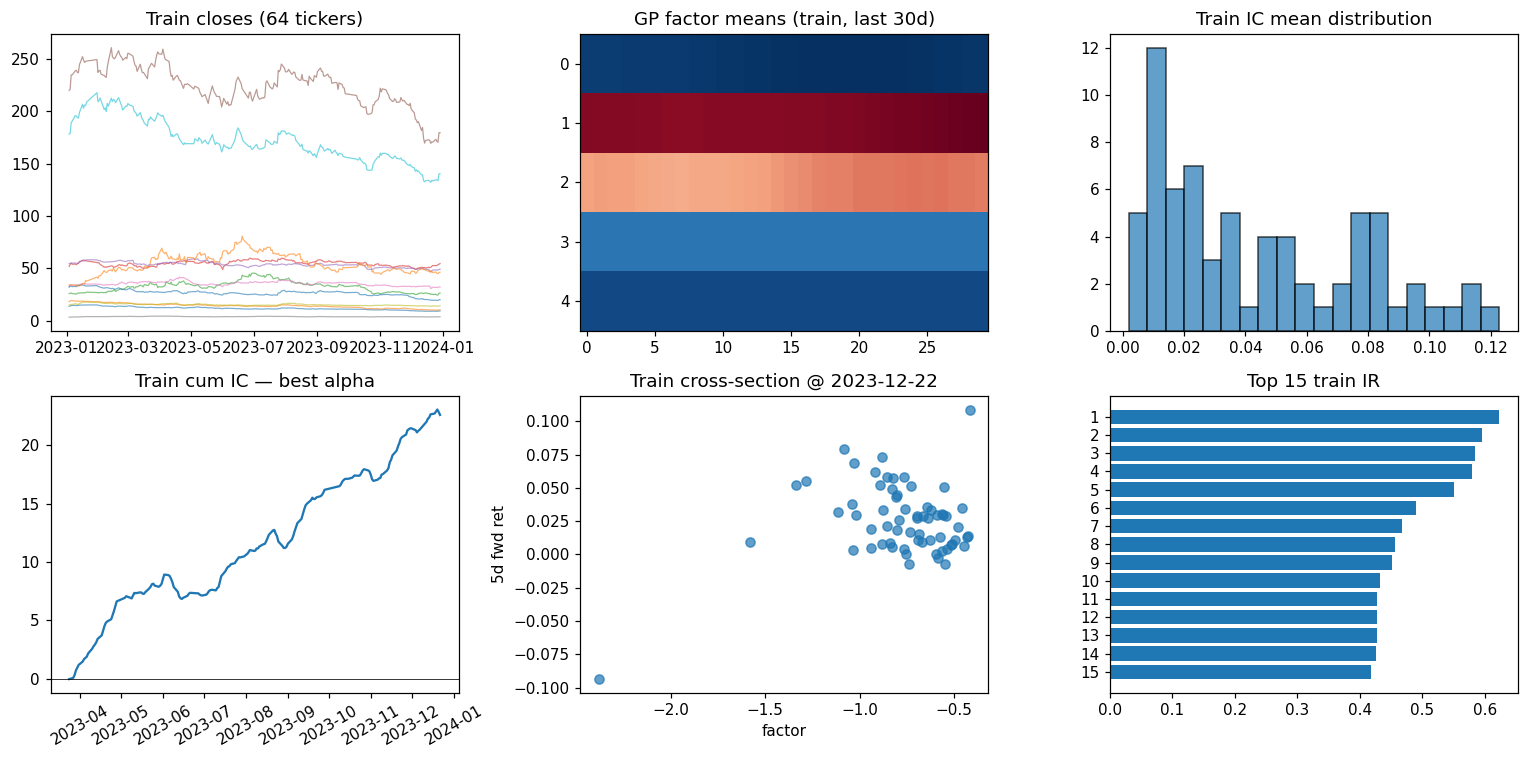

Done (in-sample).


In [11]:
show_n = min(5, len(discovered))
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

# Train Closes (Prices)
# Plot raw closing prices for the first 12 A-share tickers over time
ax = axes[0]
for sym in list(close_train.columns)[:12]:
    ax.plot(close_train.index, close_train[sym], alpha=0.6, linewidth=0.8)
ax.set_title(f"Train closes ({close_train.shape[1]} tickers)")

# GP Factor Heatmap
# Display the average signals generated by top 5 factors over the final 30 days of training
# Diverging color map: blue is buy signal and red is sell signal
if show_n:
    heat = pd.concat({f"a{i}": factors[i].iloc[-30:].mean(axis=1) for i in range(1, show_n+1)}, axis=1)
    axes[1].imshow(heat.T, aspect="auto", cmap="RdBu_r")
    axes[1].set_title("GP factor means (train, last 30d)")

# IC Mean Distribution
# A histogram showing the predictive power distribution 
axes[2].hist(catalog["ic_mean"], bins=20, edgecolor="k", alpha=0.7)
axes[2].set_title("Train IC mean distribution")

# Cumulative IC Curve
# Check the consistency, stability, and decay of factor's predictive power over time
# Cumulative IC for just one single factor: the absolute best alpha factor out of the pool
# Show highly potent, but regime-dependent alpha factor
if discovered:
    ic = daily_ic(discovered[0].values, fwd_train)
    axes[3].plot(ic.index, ic.cumsum())
    axes[3].set_title("Train cum IC — best alpha")
    axes[3].axhline(0, color="k", lw=0.5)
    axes[3].tick_params(axis='x', rotation=30)

# Cross-Sectional Reality Check
# Plot factor value vs. actual future return on the very last day
# Stocks with higher factor scores systematically deliver higher 5-day forward returns
if discovered:
    # Avoid the last 5 days where forward returns are naturally NaN
    valid_fwd_dates = fwd_train.dropna(how="all").index
    if len(valid_fwd_dates) > 0:
        dt = valid_fwd_dates[-1]  
        # Pick the last day that actually HAS forward return data
        axes[4].scatter(discovered[0].values.loc[dt], fwd_train.loc[dt], alpha=0.7)
        axes[4].set_xlabel("factor")
        axes[4].set_ylabel("5d fwd ret")
        axes[4].set_title(f"Train cross-section @ {dt.date()}")

# IR Leaderboard
# Bar chart comparing the raw IR scores of top factors
top = catalog.nlargest(15, "ir")
axes[5].barh(top["alpha_id"].astype(str), top["ir"])
axes[5].set_title("Top 15 train IR")
axes[5].invert_yaxis()

plt.tight_layout()
plt.show()
print("Done (in-sample).")
# Visualization Cell

### Out-of-Sample Stress Testing & Performance Decay Filtering

This cell subjects the train-selected alpha library to a rigorous Out-of-Sample (OOS) backtest on completely unseen historical market data. It loops through the diversified candidate pool, computes their live forecasting performance against the target horizon, and aggregates metrics. Crucially, the script calculates ir_decay to quantify how much a factor's edge degrades when transitioning out of the optimization sandbox. It then applies a quality filter requiring an in-sample baseline strength, positive predictive accuracy, and at least 40% performance retention and displays a leaderboard of those alpha signals.

In [12]:
print(f"OOS window: {close_test.index[0].date()} → {close_test.index[-1].date()}")
t0 = time.time()
oos_rows = []
# Evaluation loop
for i, sc in enumerate(discovered, 1):
    row = oos_score(sc, panel_test, fwd_test)
    if row:
        row["alpha_id"] = i
        oos_rows.append(row)
oos_df = pd.DataFrame(oos_rows)

# Sort the results by IR
effective_oos = pd.DataFrame()
if oos_df.empty:
    print("No factors produced valid OOS scores — check test window length.")
else:
    oos_df = oos_df.sort_values("oos_ir", ascending=False).reset_index(drop=True)

# Apply performance decay and quality filter
    effective_oos = oos_df[
        (oos_df["is_ir"] > 0.20) &
        (oos_df["oos_ir"] >= OOS_MIN_IR) &
        (oos_df["oos_ic_mean"] > OOS_MIN_IC) &
        (oos_df["ir_decay"] >= OOS_IR_DECAY_MIN)
    ].copy()

    print(f"Scored {len(oos_df)} factors in {time.time()-t0:.1f}s")
    print(f"Effective OOS: {len(effective_oos)} / {len(oos_df)} pass filters")
    print(f"  (oos_ir≥{OOS_MIN_IR}, oos_ic>0, ir_decay≥{OOS_IR_DECAY_MIN})")
    display(oos_df.head(15))
    if len(effective_oos):
        print("\nTop effective OOS factors:")
        display(effective_oos.head(15))


OOS window: 2024-01-02 → 2024-06-28
Scored 69 factors in 3.1s
Effective OOS: 26 / 69 pass filters
  (oos_ir≥0.1, oos_ic>0, ir_decay≥0.4)


,formula,is_ic_mean,is_ir,is_hit_rate,oos_ic_mean,oos_ir,oos_hit_rate,oos_n_days,ir_decay,complexity,alpha_id
0,"delay(mean(mean(std(delay(max(range_pct,10),20...",0.051106,0.267353,0.566667,0.221152,1.744256,0.920000,25,6.524165,7,27
1,"delay(delay(sum(min(body_pct,15),8),3),20)",0.074643,0.351331,0.668394,0.143355,0.682735,0.750000,68,1.943285,5,19
2,"delay(log(max(mean(std(max(ret,5),6),15),10)),20)",0.105658,0.595316,0.744565,0.131125,0.675491,0.766667,60,1.134675,7,2
3,"delay(log(std(sum(max(ret,5),8),8)),20)",0.079661,0.427394,0.646465,0.121975,0.609400,0.675676,74,1.425853,6,12
4,"delay(mean(mean(pressure,15),20),20)",0.047185,0.191377,0.581522,0.142274,0.609107,0.661017,59,3.182760,4,36
5,delay((mean(delay(sum(delay(sum(max(min(delay(...,0.082884,0.456028,0.681564,0.064351,0.543207,0.629630,54,1.191171,13,8
6,"delay(delay(std(sum(range_pct,8),6),3),20)",0.048616,0.280211,0.608911,0.098951,0.534271,0.701299,77,1.906675,5,24
7,"delay(sum(sum(min(delay(range_pct,10),15),8),8...",0.122803,0.622124,0.771739,0.099794,0.474950,0.627119,59,0.763433,6,1
8,"corr(volume,body_pct,20)",0.007500,0.047600,0.481651,0.075455,0.439625,0.763441,93,9.235872,3,64
9,"(sum(std(pressure,10),8)*log(std(ret,6)))",0.041328,0.247400,0.615385,0.062491,0.435783,0.656250,96,1.761446,7,30



Top effective OOS factors:


,formula,is_ic_mean,is_ir,is_hit_rate,oos_ic_mean,oos_ir,oos_hit_rate,oos_n_days,ir_decay,complexity,alpha_id
0,"delay(mean(mean(std(delay(max(range_pct,10),20...",0.051106,0.267353,0.566667,0.221152,1.744256,0.920000,25,6.524165,7,27
1,"delay(delay(sum(min(body_pct,15),8),3),20)",0.074643,0.351331,0.668394,0.143355,0.682735,0.750000,68,1.943285,5,19
2,"delay(log(max(mean(std(max(ret,5),6),15),10)),20)",0.105658,0.595316,0.744565,0.131125,0.675491,0.766667,60,1.134675,7,2
3,"delay(log(std(sum(max(ret,5),8),8)),20)",0.079661,0.427394,0.646465,0.121975,0.609400,0.675676,74,1.425853,6,12
5,delay((mean(delay(sum(delay(sum(max(min(delay(...,0.082884,0.456028,0.681564,0.064351,0.543207,0.629630,54,1.191171,13,8
6,"delay(delay(std(sum(range_pct,8),6),3),20)",0.048616,0.280211,0.608911,0.098951,0.534271,0.701299,77,1.906675,5,24
7,"delay(sum(sum(min(delay(range_pct,10),15),8),8...",0.122803,0.622124,0.771739,0.099794,0.474950,0.627119,59,0.763433,6,1
9,"(sum(std(pressure,10),8)*log(std(ret,6)))",0.041328,0.247400,0.615385,0.062491,0.435783,0.656250,96,1.761446,7,30
10,delay((mean(delay(sum(delay(sum(log(max(mean(s...,0.059593,0.336385,0.633721,0.086695,0.416686,0.687500,48,1.238718,14,22
11,"((rank(low)*log(pressure))*sum(min(-(std(ret,1...",0.074426,0.279707,0.639344,0.119627,0.413430,0.711111,45,1.478080,11,25


### Quantitative Performance Visualization & Overfitting Diagnostics

This final cell converts the out-of-sample data metrics into an analytical dashboard, providing a visual breakdown of alpha generation process through three distinct plots: OOS Cumulative IC, OOS IR Distribution, IS vs OOS IR Scatter Plot. If any evolved strategies successfully survive the performance decay filters, the engine isolates the champion factor to chart its rolling information coefficient consistency alongside structural distribution diagnostics.



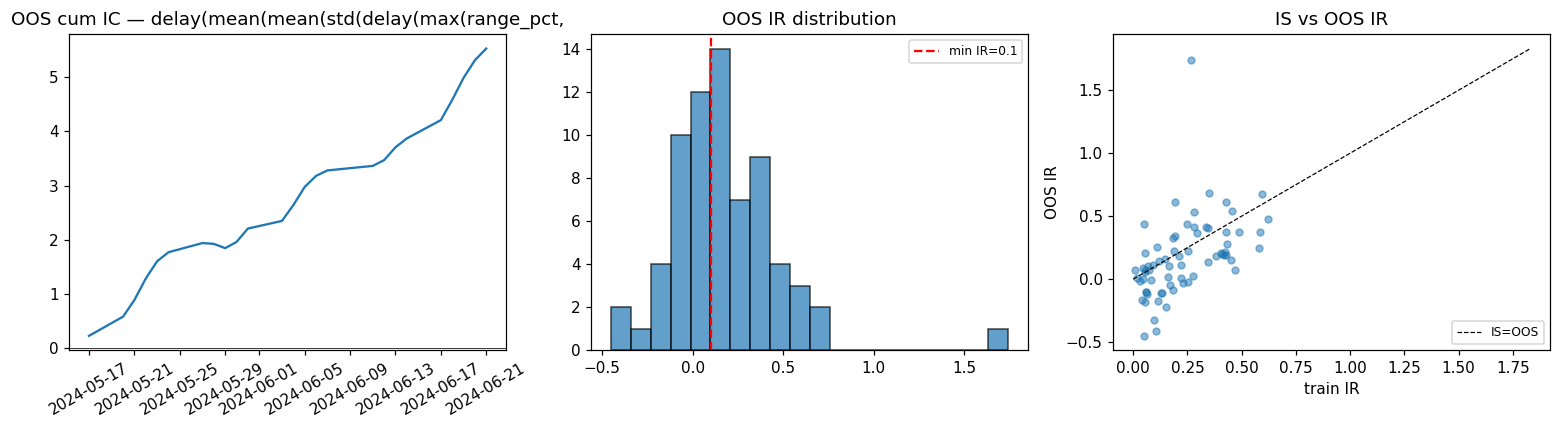

Done — nothing saved to disk.


In [13]:
# ── Step 7: OOS charts ──
if "oos_df" in dir() and not oos_df.empty and len(effective_oos):
    # Extract the champion factor
    best_formula = effective_oos.iloc[0]["formula"]
    best_sc = next(sc for sc in discovered if sc.formula == best_formula)
    vals_oos = eval_expr(best_sc.expr, panel_test) * best_sc.sign
    ic_oos = daily_ic(vals_oos, fwd_test)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # OOS Cumulative IC
    # The consistency of the champion factor's predictive edge on unseen data over time
    axes[0].plot(ic_oos.index, ic_oos.cumsum(), color="C0")
    axes[0].axhline(0, color="k", lw=0.5)
    axes[0].set_title(f"OOS cum IC — {best_formula[:40]}")
    axes[0].tick_params(axis='x', rotation=30)

    # OOS IR Distribution
    # Any bar on the right is a passing factor; left is a failed factor
    axes[1].hist(oos_df["oos_ir"], bins=20, edgecolor="k", alpha=0.7)
    axes[1].axvline(OOS_MIN_IR, color="r", ls="--", label=f"min IR={OOS_MIN_IR}")
    axes[1].set_title("OOS IR distribution")
    axes[1].legend(fontsize=8)

    # IS vs OOS IR Scatter Plot
    # The Overfitting Diagnostic
    # Every dot is a factor, with its Training IR on the X-axis and its Unseen Test IR on the Y-axis
    # If the dots cluster heavily below the line (very common), probably overfit
    axes[2].scatter(oos_df["is_ir"], oos_df["oos_ir"], alpha=0.5, s=20)
    lim = max(oos_df["is_ir"].max(), oos_df["oos_ir"].max()) * 1.05
    axes[2].plot([0, lim], [0, lim], "k--", lw=0.8, label="IS=OOS")
    axes[2].set_xlabel("train IR")
    axes[2].set_ylabel("OOS IR")
    axes[2].set_title("IS vs OOS IR")
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

else:
    print("Skip OOS charts — no effective factors passed filters.")
print("Done — nothing saved to disk.")

### Future Improvements

1. Advanced Operator Primitives: Expand the Expr engine by integrating non-linear and machine-learning-driven operators.
2. Full Portfolio Backtester: Expand the validation layer into a full asset-allocating simulation engine that converts alpha scores into actual portfolio weights. This will execute realistic rebalancing schedules that factor in China A-share stamp duties, broker commissions, and market-impact slippage to calculate realistic, net-of-fees Net Asset Value curves.
3. GPU-Accelerated Evaluation: Port the recursive eval_expr vector operations from CPU-bound Pandas/NumPy to GPU-accelerated frameworks like PyTorch to scale population and generation depth.
4. Neutralization Layer: Cross-sectional industry and risk-factor neutralization (e.g. stripping out market, sector, and size biases) to uncover pure idiosyncratic alpha.